In [7]:
#Monthly Job Postings for Top Data Jobs in the US
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [25]:
#create plot of 3 graphs about top 5 job skills demanded for Data Scientist, Data Analyst, and Data Engineer roles

#i need table with job_title_short, job_skills, count (which is grouped by job_title_short and job_skills ofc)
df_exploded = df.explode('job_skills').copy()
skill_count = df_exploded.pivot_table(index='job_title_short', columns='job_skills', aggfunc='size')
skill_count = skill_count.fillna(value=0)

In [45]:
skill_group = df_exploded.groupby(['job_title_short','job_skills']).size()
skill_group = skill_group.reset_index(name='indexxD')
skill_group = skill_group.sort_values(by='indexxD', ascending=False)
skill_group

,job_title_short,job_skills,indexxD
1066,Data Scientist,python,113711
865,Data Engineer,sql,113130
830,Data Engineer,python,108022
625,Data Analyst,sql,92428
1101,Data Scientist,sql,78982
...,...,...,...
266,Cloud Engineer,delphi,1
1920,Senior Data Scientist,objective-c,1
1400,Senior Data Analyst,couchdb,1
298,Cloud Engineer,haskell,1


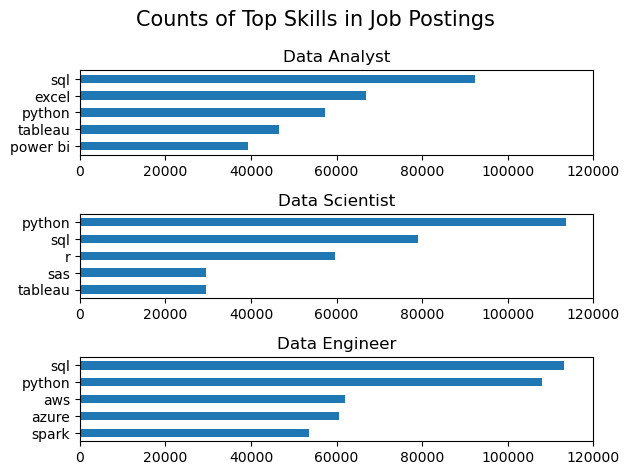

In [78]:
#plotting
data_jobs = ['Data Analyst', 'Data Scientist', 'Data Engineer']
fig,ax = plt.subplots(3,1)
for i,jobs in enumerate(data_jobs):
    skill_group[skill_group['job_title_short'] == jobs].head(5).plot(x='job_skills', y='indexxD', kind='barh', ax=ax[i], title=jobs,legend=False)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].set_xlim(0,120000)
plt.suptitle('Counts of Top Skills in Job Postings', fontsize='15')
fig.tight_layout()